<div style="background:linear-gradient(135deg,#1e2a4a 0%,#2a78d6 100%);color:#ffffff;padding:36px 32px;border-radius:14px">
  <div style="font-size:13px;letter-spacing:3px;opacity:.8">PROJET · ALTERNANCE DATA / IA</div>
  <div style="font-size:38px;font-weight:800;margin:6px 0 4px">Comprendre les LLM</div>
  <div style="font-size:17px;opacity:.92">De l'architecture Transformer à Hugging Face, en local ou via API —<br>
  dans un notebook Python pensé pour itérer vite.</div>
  <div style="margin-top:18px;font-size:13px">
    <span style="background:rgba(255,255,255,.18);padding:4px 10px;border-radius:20px;margin-right:6px">🧠 Transformers</span>
    <span style="background:rgba(255,255,255,.18);padding:4px 10px;border-radius:20px;margin-right:6px">🤗 Hugging Face</span>
    <span style="background:rgba(255,255,255,.18);padding:4px 10px;border-radius:20px;margin-right:6px">🖥️ 64 Go RAM vs API</span>
    <span style="background:rgba(255,255,255,.18);padding:4px 10px;border-radius:20px;margin-right:6px">📊 Data science</span>
    <span style="background:rgba(255,255,255,.18);padding:4px 10px;border-radius:20px">⚡ Cache des calculs longs</span>
  </div>
</div>

## 🧭 Sommaire

| # | Partie | Ce qu'on démontre |
|---|--------|-------------------|
| 0 | **Configuration & cache** | Pourquoi un notebook cellule par cellule + un cache disque pour ne jamais relancer un calcul de 30 min |
| 1 | **Architecture Transformer** | Tokens → embeddings → position → *self-attention*, codé à la main en NumPy |
| 2 | **Hugging Face** | Le Hub, tokenizer, attention d'un vrai modèle, prédiction du mot suivant avec GPT-2 |
| 3 | **64 Go de RAM ou API ?** | Calculer la mémoire d'un modèle, comparer local (open-source) et API (OpenAI) |
| 4 | **Cas data science** | Embeddings de 2 000 articles (calcul long → mis en cache), visualisation, recherche sémantique |
| 5 | **VS Code + GitHub Copilot** | Le workflow concret pour travailler vite et proprement |
| 6 | **Bilan** | Temps économisé grâce au cache, mesuré |

> 💡 **Dans VS Code** : ouvrez la vue **Outline** (barre latérale *Explorer*) — chaque titre de ce notebook devient un lien de navigation.

<div style="background:#1e2a4a;color:#ffffff;padding:18px 24px;border-radius:10px;margin-top:12px">
  <div style="font-size:12px;letter-spacing:2px;opacity:.85">PARTIE 0</div>
  <div style="font-size:26px;font-weight:700;margin-top:2px">Configuration & cache intelligent</div>
  <div style="font-size:14px;opacity:.9;margin-top:4px">Le notebook comme outil d'itération rapide</div>
</div>

### Pourquoi un notebook Jupyter, cellule par cellule ?

Un script Python classique s'exécute **de A à Z à chaque fois**. Si l'étape 2 prend 30 minutes
(télécharger un modèle, calculer des embeddings sur 100 000 textes, entraîner…), chaque petite
modification de l'étape 5 (un graphique, un filtre) coûte… 30 minutes.

Dans un notebook :

1. **Le noyau Python garde les variables en mémoire** entre les cellules → on relance seulement la cellule modifiée.
2. **On visualise au fur et à mesure** (tableaux, graphiques) → on comprend la donnée avant d'aller plus loin.
3. **Le notebook est aussi le rapport** : code + explications + résultats dans un seul fichier.

**Limite** : si le noyau redémarre (crash, fermeture de VS Code), la mémoire est perdue.
➡️ D'où le **cache disque** ci-dessous : le *résultat principal* d'un calcul long est sauvegardé
une fois, puis rechargé en une fraction de seconde.

```
 1er lancement :  [calcul 30 min] ──► résultat ──► 💾 cache/embeddings.joblib
 lancements suivants :              💾 cache/embeddings.joblib ──► résultat  (≈ 0,1 s)
```

In [1]:
# ── Paramètres du notebook : tout ce qu'on peut régler est ici ──────────────
N_TEXTES        = 2_000     # taille du corpus de la partie 4 (120_000 = dataset complet ≈ 20-30 min sur CPU)
FORCE_RECALCUL  = False     # True = ignorer le cache et tout recalculer
MODELE_API      = "gpt-4o-mini"   # modèle OpenAI utilisé en partie 3 (à adapter)
GRAINE          = 42

# ── Sur les postes 42 : modèles Hugging Face dans /goinfre (le /home est trop petit) ──
import os, getpass
if os.path.isdir("/goinfre"):
    os.environ.setdefault("HF_HOME", f"/goinfre/{getpass.getuser()}/hf")

In [2]:
import functools, hashlib, os, platform, time, warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import HTML, display

warnings.filterwarnings("ignore")
np.random.seed(GRAINE)

# ── Charte graphique : une seule palette pour tout le notebook ─────────────
BLEU, ORANGE, VERT, GRIS, ENCRE = "#2a78d6", "#eb6834", "#1baf7a", "#c3c2b7", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": ENCRE, "axes.titleweight": "bold",
    "axes.titlesize": 12, "axes.titlelocation": "left",
    "xtick.color": ENCRE, "ytick.color": ENCRE,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
})


def carte(titre, texte="", type_="info"):
    """Affiche un encadré coloré (info / succes / attention / cache)."""
    styles = {
        "info":      ("#2a78d6", "ℹ️"),
        "succes":    ("#1baf7a", "✅"),
        "attention": ("#eb6834", "⚠️"),
        "cache":     ("#7a5af8", "⚡"),
    }
    couleur, icone = styles[type_]
    display(HTML(
        f'<div style="border-left:5px solid {couleur};background:{couleur}14;'
        f'padding:10px 14px;border-radius:6px;margin:6px 0;font-family:system-ui">'
        f'<b>{icone} {titre}</b><div style="margin-top:3px;opacity:.9">{texte}</div></div>'
    ))


carte("Charte graphique chargée", "Fonctions utilitaires prêtes : <code>carte()</code>, palette, style des graphiques.", "succes")

### 💾 Le décorateur `@cache_resultat`

On « décore » une fonction lente : au premier appel elle s'exécute et son résultat est
sauvegardé sur disque (`joblib`, efficace pour les gros tableaux NumPy). Aux appels suivants,
**avec les mêmes arguments**, le résultat est relu directement.

- La clé de cache dépend des arguments → changer `N_TEXTES` déclenche un nouveau calcul, pas un faux résultat.
- `force=True` (ou `FORCE_RECALCUL = True`) pour forcer un recalcul.
- Chaque appel est journalisé → bilan chiffré à la fin du notebook.

In [3]:
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
JOURNAL = []   # historique des appels (pour le bilan final)


def cache_resultat(nom):
    def decorateur(fonction):
        @functools.wraps(fonction)
        def wrapper(*args, force=False, **kwargs):
            cle = hashlib.md5(repr((args, sorted(kwargs.items()))).encode()).hexdigest()[:10]
            fichier = CACHE_DIR / f"{nom}_{cle}.joblib"

            if fichier.exists() and not (force or FORCE_RECALCUL):
                t0 = time.perf_counter()
                paquet = joblib.load(fichier)
                duree_lecture = time.perf_counter() - t0
                JOURNAL.append({"étape": nom, "source": "cache",
                                "durée du calcul (s)": paquet["duree"], "durée réelle (s)": duree_lecture})
                carte(f"{nom} — chargé depuis le cache en {duree_lecture:.2f} s",
                      f"Calcul initial : {paquet['duree']:.1f} s, le {paquet['date']}. "
                      f"<b>{paquet['duree'] - duree_lecture:.1f} s économisées.</b>", "cache")
                return paquet["resultat"]

            t0 = time.perf_counter()
            resultat = fonction(*args, **kwargs)
            duree = time.perf_counter() - t0
            joblib.dump({"resultat": resultat, "duree": duree,
                         "date": datetime.now().strftime("%d/%m/%Y %H:%M")}, fichier)
            JOURNAL.append({"étape": nom, "source": "calcul",
                            "durée du calcul (s)": duree, "durée réelle (s)": duree})
            carte(f"{nom} — calculé en {duree:.1f} s et mis en cache",
                  f"Fichier : <code>{fichier}</code>", "succes")
            return resultat
        return wrapper
    return decorateur

#### 🧪 Démonstration : une fonction « lente »

Exécutez la cellule **deux fois** (`Shift + Entrée`) : la première prend ~5 s, la seconde est instantanée.

In [4]:
@cache_resultat("demo_fonction_lente")
def fonction_lente(n):
    time.sleep(5)                       # simule un calcul de 30 minutes
    return sum(i * i for i in range(n))


fonction_lente(1_000_000)

333332833333500000

### 🖥️ La machine sur laquelle tourne ce notebook

In [5]:
ram_go = psutil.virtual_memory().total / 1024**3
try:
    import torch
    gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "aucun (CPU)"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    gpu, DEVICE = "torch non installé", "cpu"

display(pd.DataFrame({
    "Ressource": ["Système", "Python", "CPU (cœurs logiques)", "RAM totale", "RAM disponible", "GPU"],
    "Valeur": [platform.system(), platform.python_version(), psutil.cpu_count(),
               f"{ram_go:.1f} Go", f"{psutil.virtual_memory().available / 1024**3:.1f} Go", gpu],
}).set_index("Ressource"))

if ram_go < 60:
    carte(f"{ram_go:.0f} Go de RAM détectés",
          "Suffisant pour ce notebook (petits modèles). Pour faire tourner un LLM de 7 à 13 milliards "
          "de paramètres en local, il faut viser 64 Go → voir la partie 3.", "attention")
else:
    carte(f"{ram_go:.0f} Go de RAM détectés", "Assez pour des LLM open-source de 7-13 milliards de paramètres en local.", "succes")

,Valeur
Ressource,
Système,Linux
Python,3.10.12
CPU (cœurs logiques),16
RAM totale,15.3 Go
RAM disponible,8.8 Go
GPU,aucun (CPU)


<div style="background:#2a78d6;color:#ffffff;padding:18px 24px;border-radius:10px;margin-top:12px">
  <div style="font-size:12px;letter-spacing:2px;opacity:.85">PARTIE 1</div>
  <div style="font-size:26px;font-weight:700;margin-top:2px">L'architecture Transformer</div>
  <div style="font-size:14px;opacity:.9;margin-top:4px">« Attention Is All You Need » (Vaswani et al., 2017) — reconstruite pas à pas en NumPy</div>
</div>

### Vue d'ensemble

Un LLM (GPT, Llama, Mistral, Claude…) est une pile de **blocs Transformer** identiques.
Son seul travail : **prédire le token suivant**, encore et encore.

```
  "Le chat mange la"
         │
   ① Tokenisation        texte → identifiants entiers     [412, 8813, 2271, 1045]
         │
   ② Embeddings          chaque id → vecteur de d nombres  (d = 768 pour GPT-2)
         │
   ③ + Encodage positionnel   on injecte l'ordre des mots
         │
   ┌─────▼──────────────────────────────┐
   │ ④ Multi-Head Self-Attention        │  chaque mot « regarde » les autres
   │    + connexion résiduelle + Norm   │
   │ ⑤ Feed-Forward (MLP)               │  chaque mot est transformé seul
   │    + connexion résiduelle + Norm   │
   └─────┬──────────────────────────────┘
         │   × N couches  (12 pour GPT-2, 32 pour Llama-3-8B, 80 pour 70B)
         │
   ⑥ Projection vers le vocabulaire → probabilités  → « souris » 41 %, « pâtée » 12 %…
```

**Deux familles** :
- **Encodeur** (BERT) : chaque mot voit toute la phrase → compréhension, classification, embeddings.
- **Décodeur** (GPT, Llama) : chaque mot ne voit que le passé (*masque causal*) → génération de texte.

### ① ② Tokenisation et embeddings (version jouet)

Ici un vocabulaire minuscule ; un vrai tokenizer est montré en partie 2.

In [6]:
phrase = ["le", "chat", "mange", "la", "souris"]
vocab = {mot: i for i, mot in enumerate(sorted(set(phrase)))}
ids = np.array([vocab[m] for m in phrase])

D_MODEL = 16                                           # taille d'un vecteur (768 dans GPT-2)
table_embeddings = np.random.randn(len(vocab), D_MODEL) * 0.5   # apprise pendant l'entraînement
X = table_embeddings[ids]                              # (nb_tokens, D_MODEL)

print("ids des tokens :", ids)
print("matrice X      :", X.shape, "→ un vecteur de", D_MODEL, "nombres par mot")

ids des tokens : [2 0 3 1 4]
matrice X      : (5, 16) → un vecteur de 16 nombres par mot


### ③ Encodage positionnel

L'attention ne connaît pas l'ordre des mots (« le chat mange la souris » = « la souris mange le chat »).
On ajoute donc à chaque embedding un motif de sinus/cosinus unique à sa position.

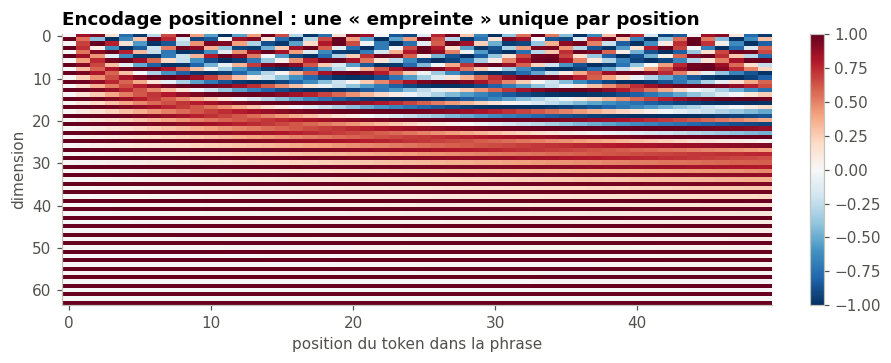

In [7]:
def encodage_positionnel(nb_positions, d_model):
    pos = np.arange(nb_positions)[:, None]
    i = np.arange(d_model)[None, :]
    angles = pos / np.power(10_000, (2 * (i // 2)) / d_model)
    pe = np.zeros((nb_positions, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe


fig, ax = plt.subplots(figsize=(9, 3.2))
im = ax.imshow(encodage_positionnel(50, 64).T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set(title="Encodage positionnel : une « empreinte » unique par position",
       xlabel="position du token dans la phrase", ylabel="dimension")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.025)
plt.show()

X = X + encodage_positionnel(len(phrase), D_MODEL)

### ④ Le cœur : la *self-attention*

Chaque token produit trois vecteurs via trois matrices apprises :

| Vecteur | Rôle | Analogie |
|---|---|---|
| **Q** (*query*) | ce que je cherche | la question posée |
| **K** (*key*) | ce que je contiens | l'étiquette d'un dossier |
| **V** (*value*) | l'information transmise | le contenu du dossier |

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Le score $QK^\top$ mesure à quel point chaque mot est pertinent pour chaque autre ;
le *softmax* transforme ces scores en pourcentages ; on fait la moyenne pondérée des $V$.

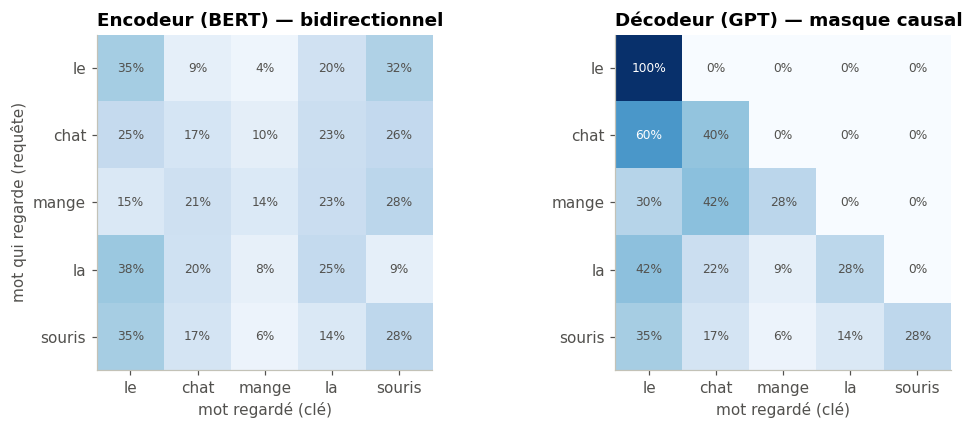

In [8]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)           # stabilité numérique
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


def attention(Q, K, V, masque=None):
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-1, -2) / np.sqrt(d_k)
    if masque is not None:
        scores = np.where(masque, scores, -1e9)      # -inf → poids 0 après softmax
    poids = softmax(scores)
    return poids @ V, poids


W_q, W_k, W_v = (np.random.randn(D_MODEL, D_MODEL) * 0.4 for _ in range(3))
Q, K, V = X @ W_q, X @ W_k, X @ W_v

masque_causal = np.tril(np.ones((len(phrase), len(phrase)), dtype=bool))
_, poids_bert = attention(Q, K, V)                     # encodeur : voit tout
_, poids_gpt = attention(Q, K, V, masque_causal)      # décodeur : voit le passé

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, poids, titre in [(axes[0], poids_bert, "Encodeur (BERT) — bidirectionnel"),
                         (axes[1], poids_gpt, "Décodeur (GPT) — masque causal")]:
    ax.imshow(poids, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(phrase)), phrase); ax.set_yticks(range(len(phrase)), phrase)
    ax.set_title(titre); ax.set_xlabel("mot regardé (clé)"); ax.grid(False)
    for i in range(len(phrase)):
        for j in range(len(phrase)):
            ax.text(j, i, f"{poids[i, j]:.0%}", ha="center", va="center", fontsize=8,
                    color="white" if poids[i, j] > 0.5 else ENCRE)
axes[0].set_ylabel("mot qui regarde (requête)")
plt.tight_layout(); plt.show()

carte("Lecture", "Chaque ligne somme à 100 %. À droite, le triangle supérieur est vide : "
      "GPT ne peut pas « tricher » en regardant les mots futurs qu'il doit prédire. "
      "(Poids aléatoires ici : non entraînés, les motifs n'ont pas encore de sens.)")

### ⑤ Ce qu'il faut retenir

- Un Transformer = **embeddings + N × (attention + MLP)** + une couche finale vers le vocabulaire.
- L'**attention** permet à chaque mot de récupérer l'information des autres, **en parallèle** (contrairement aux RNN) → entraînement massif sur GPU possible → d'où l'explosion des LLM.
- Toute la « connaissance » est dans les **matrices de poids** (W_q, W_k, W_v, MLP…). Leur nombre total = le nombre de paramètres → c'est ce qui dicte la RAM nécessaire (partie 3).

<div style="background:#eb6834;color:#ffffff;padding:18px 24px;border-radius:10px;margin-top:12px">
  <div style="font-size:12px;letter-spacing:2px;opacity:.85">PARTIE 2</div>
  <div style="font-size:26px;font-weight:700;margin-top:2px">Hugging Face 🤗</div>
  <div style="font-size:14px;opacity:.9;margin-top:4px">Le « GitHub des modèles » : 1M+ modèles pré-entraînés, utilisables en 3 lignes</div>
</div>

### L'écosystème

| Brique | Rôle |
|---|---|
| **Hub** (huggingface.co) | Héberge modèles, datasets et démos (*Spaces*). Ex. `meta-llama/Llama-3.1-8B`, `mistralai/Mistral-7B` |
| `transformers` | Charger / utiliser / fine-tuner n'importe quel modèle avec la même API (`AutoTokenizer`, `AutoModel`) |
| `datasets` | Charger des jeux de données en une ligne, en streaming si besoin |
| `sentence-transformers` | Modèles d'embeddings (recherche sémantique, clustering, RAG) |

Les modèles téléchargés sont mis en cache dans `~/.cache/huggingface` : **le téléchargement n'a lieu qu'une fois**.
Les modèles ci-dessous sont petits (< 500 Mo) pour tourner sur n'importe quel laptop.

In [9]:
import torch
from transformers import AutoModel, AutoModelForCausalLM, AutoTokenizer
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
torch.manual_seed(GRAINE)
carte("Bibliothèques Hugging Face importées", f"transformers prêt — calculs sur <b>{DEVICE}</b>.", "succes")

### Niveau 1 — Le tokenizer réel : texte → tokens

Les LLM ne lisent pas des mots mais des **sous-mots** (*BPE*). Conséquence business :
**les API facturent au token**, et le français consomme plus de tokens que l'anglais.

In [10]:
tokenizer_gpt2 = AutoTokenizer.from_pretrained("gpt2")
COULEURS_TOKENS = ["#dbe8f8", "#fbe1d6", "#d3f0e5", "#fbecc7", "#f8dde8"]


def afficher_tokens(texte, tokenizer):
    tokens = tokenizer.tokenize(texte)
    puces = "".join(
        f'<span style="background:{COULEURS_TOKENS[i % 5]};color:#0b0b0b;padding:2px 4px;margin:1px;'
        f'border-radius:4px;font-family:monospace">{t.replace("Ġ", "␣")}</span>'
        for i, t in enumerate(tokens))
    display(HTML(f'<div style="margin:6px 0"><b>{len(tokens)} tokens</b> pour {len(texte)} caractères'
                 f'<br><div style="margin-top:4px;line-height:2">{puces}</div></div>'))


afficher_tokens("The cat is eating the mouse in the kitchen.", tokenizer_gpt2)
afficher_tokens("Le chat est en train de manger la souris dans la cuisine.", tokenizer_gpt2)
print("ids :", tokenizer_gpt2.encode("Le chat mange la souris"))

ids : [3123, 8537, 582, 469, 8591, 11348, 271]


### Niveau 2 — Regarder l'attention d'un vrai modèle (DistilBERT)

Même calcul que notre version NumPy, mais avec des poids **entraînés** : les motifs ont maintenant un sens.
On affiche la tête qui relie le plus le pronom **« it »** à **« animal »**.

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11326.16it/s]

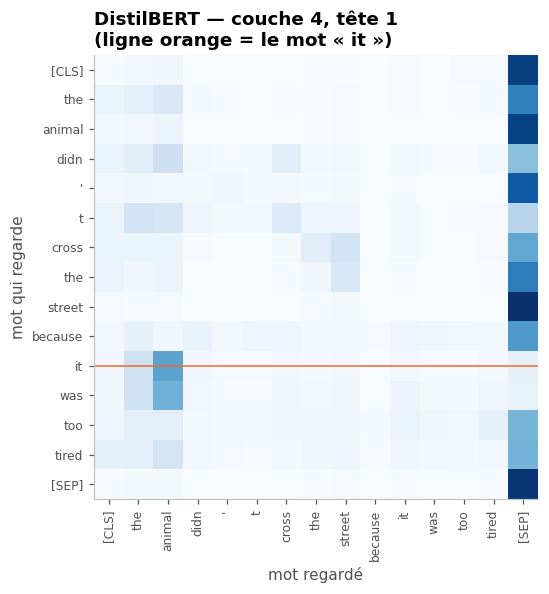

In [11]:
tok_bert = AutoTokenizer.from_pretrained("distilbert-base-uncased")
modele_bert = AutoModel.from_pretrained("distilbert-base-uncased", output_attentions=True).eval()

texte = "The animal didn't cross the street because it was too tired"
entrees = tok_bert(texte, return_tensors="pt")
with torch.no_grad():
    sorties = modele_bert(**entrees)

tokens = tok_bert.convert_ids_to_tokens(entrees["input_ids"][0])
COUCHE = 4                                                   # 6 couches dans DistilBERT (0 à 5)
attn = sorties.attentions[COUCHE][0].numpy()                 # (12 têtes, n, n)
idx_it = tokens.index("it")

TETE = int(attn[:, idx_it, tokens.index("animal")].argmax())   # la tête qui relie le plus « it » à « animal »

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(attn[TETE], cmap="Blues", vmin=0, vmax=attn[TETE].max())
ax.axhline(idx_it, color=ORANGE, lw=1)
ax.set_xticks(range(len(tokens)), tokens, rotation=90, fontsize=8)
ax.set_yticks(range(len(tokens)), tokens, fontsize=8)
ax.set(title=f"DistilBERT — couche {COUCHE}, tête {TETE}\n(ligne orange = le mot « it »)",
       xlabel="mot regardé", ylabel="mot qui regarde")
ax.grid(False)
plt.tight_layout(); plt.show()

poids_it = pd.Series(attn[:, idx_it, :].mean(0), index=tokens).drop(["[CLS]", "[SEP]", "it"])
carte("Vers quoi « it » regarde-t-il ? (moyenne des 12 têtes)",
      " · ".join(f"<b>{t}</b> {p:.0%}" for t, p in poids_it.nlargest(4).items())
      + "<br><i>La colonne [SEP] très foncée est un phénomène connu : quand une tête n'a rien de pertinent "
        "à regarder, elle « se repose » sur ce token spécial.</i>")

### Niveau 3 — GPT-2 : prédire le mot suivant

C'est **littéralement tout ce que fait un LLM**. ChatGPT répète cette opération token après token.

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 12908.50it/s]

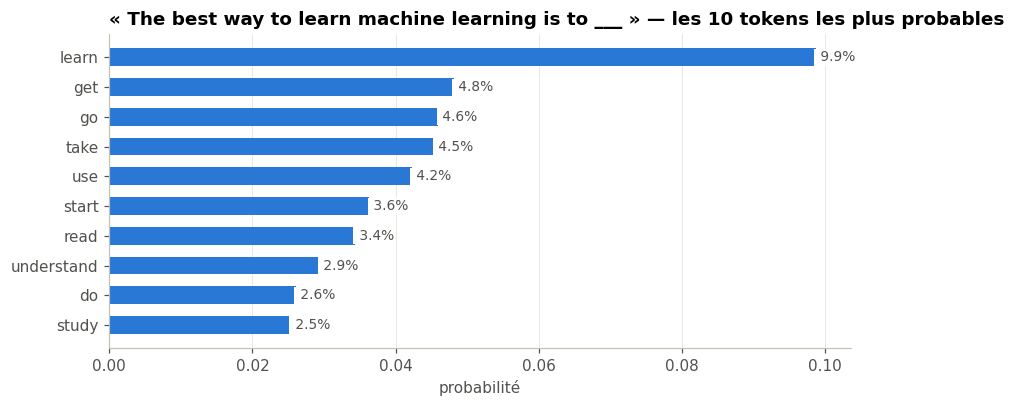

In [12]:
modele_gpt2 = AutoModelForCausalLM.from_pretrained("gpt2").eval()

debut = "The best way to learn machine learning is to"
entrees = tokenizer_gpt2(debut, return_tensors="pt")
with torch.no_grad():
    logits = modele_gpt2(**entrees).logits[0, -1]        # scores pour le DERNIER token
probas = torch.softmax(logits, dim=-1)
top = torch.topk(probas, 10)
candidats = [tokenizer_gpt2.decode(i).strip() or repr(tokenizer_gpt2.decode(i)) for i in top.indices]

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(candidats[::-1], top.values.numpy()[::-1], color=BLEU, height=0.6)
for y, v in enumerate(top.values.numpy()[::-1]):
    ax.text(v, y, f" {v:.1%}", va="center", fontsize=9, color=ENCRE,
            bbox=dict(facecolor="white", edgecolor="none", pad=1))
ax.set(title=f"« {debut} ___ » — les 10 tokens les plus probables", xlabel="probabilité")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [13]:
for temperature in (0.3, 1.2):
    sortie = modele_gpt2.generate(**entrees, max_new_tokens=30, do_sample=True, temperature=temperature,
                                  top_p=0.95, pad_token_id=tokenizer_gpt2.eos_token_id)
    carte(f"Génération — température {temperature}",
          tokenizer_gpt2.decode(sortie[0], skip_special_tokens=True),
          "info" if temperature < 1 else "attention")

carte("La température", "Basse = choix prudents et répétitifs. Haute = créatif mais risque d'incohérence. "
      "GPT-2 (2019, 124 M paramètres) est 1 000 fois plus petit que les LLM actuels — d'où la qualité limitée.")

<div style="background:#1baf7a;color:#ffffff;padding:18px 24px;border-radius:10px;margin-top:12px">
  <div style="font-size:12px;letter-spacing:2px;opacity:.85">PARTIE 3</div>
  <div style="font-size:26px;font-weight:700;margin-top:2px">64 Go de RAM ou API ?</div>
  <div style="font-size:14px;opacity:.9;margin-top:4px">Deux façons d'utiliser un LLM, et comment dimensionner la machine</div>
</div>

### Deux stratégies

| | 🖥️ **Modèle open-source en local** (Hugging Face) | ☁️ **API** (OpenAI, Anthropic, Mistral…) |
|---|---|---|
| Où tourne le modèle | Sur **votre** machine → il doit tenir en RAM / VRAM | Sur les serveurs du fournisseur |
| RAM nécessaire | **Élevée** : dépend du nombre de paramètres (calcul ci-dessous) | Faible : on envoie du texte, on reçoit du texte |
| Coût | Matériel (une fois) | Au token, à chaque appel |
| Données | Restent en interne ✅ (RGPD, secret industriel) | Envoyées à un tiers |
| Qualité | Bonne (Llama, Mistral, Qwen) | Meilleure sur les tâches complexes |

**Pourquoi 64 Go ?** Pour un poste data science qui fait les deux : faire tourner des modèles open-source
de 7 à 13 milliards de paramètres en local, **tout en** gardant de la marge pour pandas, les embeddings
de gros corpus, le notebook, VS Code et Docker. Côté API, la RAM n'est pas le goulot : c'est le volume de
données que l'on prépare et analyse autour des appels.

### La règle de calcul

$$\text{RAM} \approx \text{nb de paramètres} \times \text{octets par paramètre} \times 1{,}2$$

(le ×1,2 couvre les activations et le *KV-cache* du contexte). Octets par paramètre selon la précision :
**float32 = 4**, **float16 = 2**, **int8 = 1**, **int4 = 0,5** (quantification).

In [14]:
OCTETS = {"float32": 4, "float16": 2, "int8": 1, "int4": 0.5}
MODELES = {"GPT-2 (0,12 Md)": 0.124, "Mistral-7B": 7.2, "Llama-3.1-8B": 8.0,
           "Llama-2-13B": 13.0, "Mixtral-8x7B": 46.7, "Llama-3.1-70B": 70.6}


def ram_necessaire_go(milliards_params, precision):
    return milliards_params * 1e9 * OCTETS[precision] * 1.2 / 1024**3


tableau = pd.DataFrame({p: {m: ram_necessaire_go(n, p) for m, n in MODELES.items()} for p in OCTETS})


def colorer(v):
    if v <= 16:  return "background-color:#d3f0e5;color:#0b0b0b"
    if v <= 64:  return "background-color:#fbecc7;color:#0b0b0b"
    return "background-color:#fbe1d6;color:#0b0b0b"


display(tableau.style.format("{:.1f} Go").map(colorer)
        .set_caption("RAM estimée — vert : laptop 16 Go · jaune : poste 64 Go · rouge : serveur GPU"))

# vérification avec un vrai modèle déjà chargé
n_params_gpt2 = sum(p.numel() for p in modele_gpt2.parameters())
taille_reelle = sum(p.numel() * p.element_size() for p in modele_gpt2.parameters()) / 1024**3
carte("Vérification sur GPT-2 chargé en mémoire",
      f"{n_params_gpt2 / 1e6:.0f} M paramètres × 4 octets = {taille_reelle:.2f} Go de poids "
      f"(formule : {n_params_gpt2 * 4 / 1024**3:.2f} Go) ✔")

,float32,float16,int8,int4
"GPT-2 (0,12 Md)",0.6 Go,0.3 Go,0.1 Go,0.1 Go
Mistral-7B,32.2 Go,16.1 Go,8.0 Go,4.0 Go
Llama-3.1-8B,35.8 Go,17.9 Go,8.9 Go,4.5 Go
Llama-2-13B,58.1 Go,29.1 Go,14.5 Go,7.3 Go
Mixtral-8x7B,208.8 Go,104.4 Go,52.2 Go,26.1 Go
Llama-3.1-70B,315.6 Go,157.8 Go,78.9 Go,39.5 Go


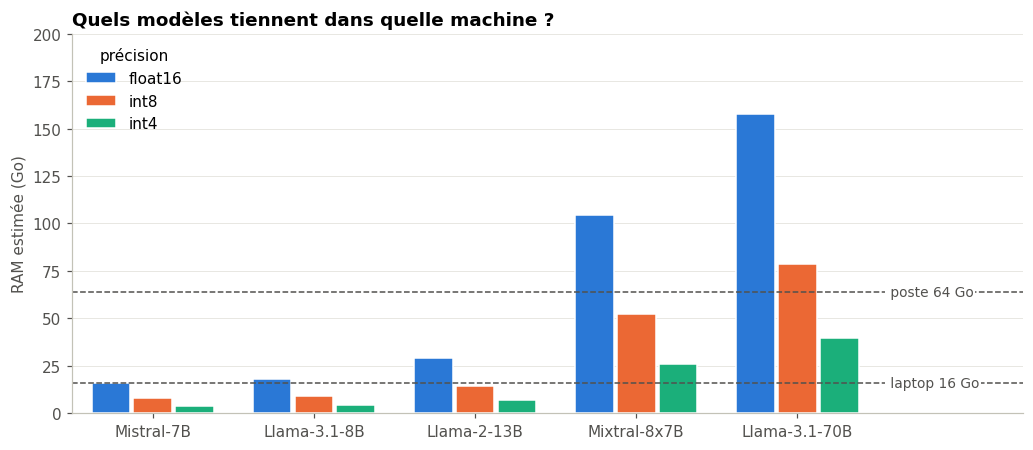

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
modeles = list(MODELES)[1:]                                # GPT-2 est invisible à cette échelle
x = np.arange(len(modeles))
for k, (precision, couleur) in enumerate([("float16", BLEU), ("int8", ORANGE), ("int4", VERT)]):
    ax.bar(x + (k - 1) * 0.26, tableau.loc[modeles, precision], width=0.24, color=couleur,
           label=precision, edgecolor="white", linewidth=1)
for seuil, nom in [(16, "laptop 16 Go"), (64, "poste 64 Go")]:
    ax.axhline(seuil, color=ENCRE, lw=1, ls="--")
    ax.text(len(modeles) - 0.45, seuil, f" {nom}", ha="left", va="center", fontsize=9, color=ENCRE,
            bbox=dict(facecolor="white", edgecolor="none", pad=1))
ax.set_xticks(x, modeles)
ax.set(title="Quels modèles tiennent dans quelle machine ?", ylabel="RAM estimée (Go)", ylim=(0, 200),
       xlim=(-0.5, len(modeles) + 0.4))
ax.legend(title="précision", frameon=False, loc="upper left")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

carte("Conclusion", "Avec 64 Go : Mistral-7B / Llama-8B en float16, Llama-13B en int8, et même Mixtral en int4. "
      "Avec 16 Go : seulement les 7-8B fortement quantifiés, et plus de place pour les données.", "succes")

### ☁️ Appel API (OpenAI) — avec cache

Chaque appel API **coûte de l'argent et du temps**. Le même décorateur `@cache_resultat`
évite de repayer une question déjà posée pendant qu'on itère sur l'analyse.

Pour l'activer : créer une clé sur platform.openai.com puis, dans un terminal, `export OPENAI_API_KEY="sk-..."`
avant de lancer VS Code (ou un fichier `.env` **jamais commité sur GitHub**). Sans clé, la cellule s'affiche proprement sans planter.

In [16]:
@cache_resultat("appel_api_openai")
def demander_llm(question, modele=MODELE_API):
    from openai import OpenAI
    client = OpenAI()                                      # lit OPENAI_API_KEY dans l'environnement
    reponse = client.chat.completions.create(
        model=modele,
        messages=[{"role": "system", "content": "Tu es un expert en IA. Réponds en 3 phrases maximum."},
                  {"role": "user", "content": question}])
    return {"texte": reponse.choices[0].message.content,
            "tokens_entree": reponse.usage.prompt_tokens, "tokens_sortie": reponse.usage.completion_tokens}


if os.getenv("OPENAI_API_KEY"):
    r = demander_llm("Explique le mécanisme d'attention d'un Transformer à un débutant.")
    carte(f"Réponse de {MODELE_API}", r["texte"])
    print(f"tokens : {r['tokens_entree']} en entrée, {r['tokens_sortie']} en sortie")
else:
    carte("Pas de clé OPENAI_API_KEY détectée",
          "Démonstration API ignorée. Tout le reste du notebook fonctionne en local, sans clé.", "attention")

<div style="background:#7a5af8;color:#ffffff;padding:18px 24px;border-radius:10px;margin-top:12px">
  <div style="font-size:12px;letter-spacing:2px;opacity:.85">PARTIE 4</div>
  <div style="font-size:26px;font-weight:700;margin-top:2px">Cas pratique data science</div>
  <div style="font-size:14px;opacity:.9;margin-top:4px">Analyser un corpus d'articles avec des embeddings — le calcul long est mis en cache</div>
</div>

### Le problème

On a des milliers d'articles de presse (*AG News* : World, Sports, Business, Sci/Tech).
**Objectif** : sans lire un seul article, les regrouper par thème et pouvoir chercher par le sens (pas par mot-clé).

**Méthode** : un modèle Transformer (encodeur) convertit chaque texte en un **embedding** de 384 nombres.
Deux textes au sens proche → vecteurs proches. C'est la base de la recherche sémantique et du **RAG**.

⏱️ C'est l'étape lente : ~1 min pour 2 000 textes sur CPU, **20-30 min pour les 120 000**.
C'est exactement le cas d'usage du cache : on la calcule **une fois**, puis on itère librement sur l'analyse.

In [17]:
MODELE_EMBEDDINGS = "sentence-transformers/all-MiniLM-L6-v2"
NOMS_THEMES = ["World", "Sports", "Business", "Sci/Tech"]


@cache_resultat("embeddings_ag_news")
def calculer_embeddings(n_textes, nom_modele=MODELE_EMBEDDINGS):
    from datasets import load_dataset
    from sentence_transformers import SentenceTransformer

    ds = load_dataset("fancyzhx/ag_news", split="train").shuffle(seed=GRAINE).select(range(n_textes))
    modele = SentenceTransformer(nom_modele, device=DEVICE)
    embeddings = modele.encode(ds["text"], batch_size=64, show_progress_bar=True,
                               normalize_embeddings=True)
    return {"textes": list(ds["text"]), "labels": np.array(ds["label"]), "embeddings": embeddings}


corpus = calculer_embeddings(N_TEXTES)          # ← l'appel long : relancez la cellule pour voir le cache
E = corpus["embeddings"]
print(f"Matrice d'embeddings : {E.shape[0]} textes × {E.shape[1]} dimensions")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10618.75it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   3%|▎         | 1/32 [00:01<00:41,  1.34s/it]

Batches:   6%|▋         | 2/32 [00:01<00:28,  1.07it/s]

...

Batches:  91%|█████████ | 29/32 [00:11<00:00,  3.81it/s]

Batches:  94%|█████████▍| 30/32 [00:11<00:00,  3.95it/s]

Batches:  97%|█████████▋| 31/32 [00:11<00:00,  4.18it/s]

Batches: 100%|██████████| 32/32 [00:11<00:00,  2.74it/s]

Matrice d'embeddings : 2000 textes × 384 dimensions


### Exploration : les thèmes se séparent-ils naturellement ?

On projette les 384 dimensions en 2 avec une **PCA**. Une vue par thème (le thème en couleur, les autres en gris) :
plus lisible que 4 couleurs mélangées.

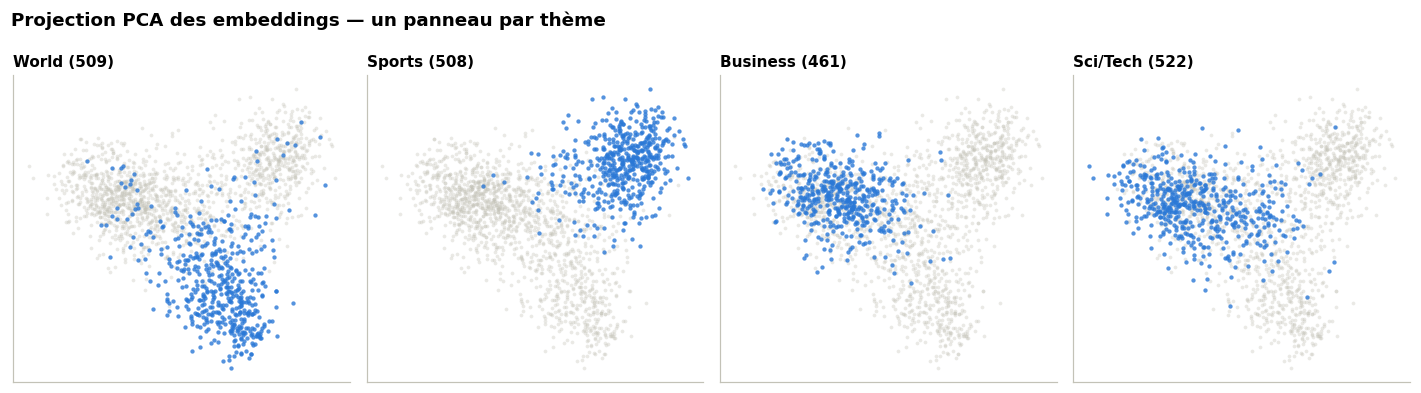

In [18]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=GRAINE).fit_transform(E)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharex=True, sharey=True)
for k, (ax, theme) in enumerate(zip(axes, NOMS_THEMES)):
    dans = corpus["labels"] == k
    ax.scatter(*coords[~dans].T, s=6, color=GRIS, alpha=0.35, linewidths=0)
    ax.scatter(*coords[dans].T, s=8, color=BLEU, alpha=0.8, linewidths=0)
    ax.set_title(f"{theme} ({dans.sum()})", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Projection PCA des embeddings — un panneau par thème",
             x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

carte("Lecture", "Sports et World forment des groupes bien distincts ; Business et Sci/Tech se chevauchent "
      "(beaucoup d'articles parlent d'entreprises tech).")

### Recherche sémantique (le « R » de RAG)

On encode une question et on cherche les articles dont l'embedding est le plus proche (similarité cosinus).
Les mots de la question n'ont **pas besoin** d'apparaître dans les articles.

In [19]:
from sentence_transformers import SentenceTransformer

encodeur = SentenceTransformer(MODELE_EMBEDDINGS, device=DEVICE)   # déjà en cache HF → rapide


def rechercher(question, k=5):
    q = encodeur.encode([question], normalize_embeddings=True)[0]
    scores = E @ q                                    # vecteurs normalisés → produit scalaire = cosinus
    meilleurs = np.argsort(-scores)[:k]
    return pd.DataFrame({"similarité": scores[meilleurs].round(3),
                         "thème": [NOMS_THEMES[corpus["labels"][i]] for i in meilleurs],
                         "article": [corpus["textes"][i][:140] + "…" for i in meilleurs]})


QUESTION = "economic consequences of rising oil prices"   # ← modifiez et relancez seulement cette cellule
display(rechercher(QUESTION).style.hide(axis="index").set_properties(subset=["article"], **{"text-align": "left"}))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11017.09it/s]

similarité,thème,article
0.705000,Business,\$50-plus Oil Drags on Economy Oil prices above \$50 a barrel -nd rising - now starting to adversely affect the economy and consumers in wa…
0.690000,Business,\$50-plus oil drags on economy Oil prices above \$50 a barrel - and rising - are now starting to adversely affect the economy and consumers …
0.622000,Business,"Oil Hits \$50 and Bounces Back Under \$49 NEW YORK (Reuters) - Oil prices rose on Tuesday but retreated from an earlier break above \$50, …"
0.592000,Business,Update 3: Oil Prices Drop \$1 Despite Iraq Sabotage Oil futures dropped by nearly \$1 per barrel Monday despite pipeline sabotage in Iraq th…
0.588000,Business,"Markets rise amid falling oil prices A slide in the price of oil gave stock markets a lift this afternoon, but gains in Toronto were sharply…"


<div style="background:#52514e;color:#ffffff;padding:18px 24px;border-radius:10px;margin-top:12px">
  <div style="font-size:12px;letter-spacing:2px;opacity:.85">PARTIE 5</div>
  <div style="font-size:26px;font-weight:700;margin-top:2px">VS Code + GitHub Copilot</div>
  <div style="font-size:14px;opacity:.9;margin-top:4px">Le workflow concret derrière ce notebook</div>
</div>

### ⌨️ Les gestes essentiels dans VS Code

| Action | Raccourci / Où |
|---|---|
| Exécuter la cellule et passer à la suivante | `Shift + Entrée` |
| Exécuter la cellule sans bouger | `Ctrl + Entrée` |
| Exécuter tout ce qui est au-dessus | bouton `⋯` de la cellule → *Execute Above Cells* |
| Voir toutes les variables en mémoire (taille, type, aperçu des DataFrames) | barre du notebook → **Variables** |
| Naviguer par titres | **Outline** dans l'Explorer |
| Redémarrer le noyau (libérer la RAM) | barre du notebook → **Restart** — le cache disque, lui, survit ✅ |
| Choisir l'environnement Python | en haut à droite → **Select Kernel** → `.venv` |

### 🤖 GitHub Copilot dans un notebook

| Usage | Comment |
|---|---|
| **Complétion** | écrire un commentaire `# tracer l'histogramme de la longueur des articles` → `Tab` pour accepter |
| **Générer une cellule** | `Ctrl + I` dans une cellule → décrire en français ce qu'on veut |
| **Comprendre du code** | sélectionner → Copilot Chat → `/explain` (idéal pour la cellule *multi-head attention*) |
| **Corriger une erreur** | après une exception, bouton **Fix** / `/fix` : Copilot lit la trace d'erreur |
| **Documenter / tester** | `/doc`, `/tests` sur une fonction (ex. `ram_necessaire_go`) |

> ⚠️ **Bonne pratique** : Copilot propose, **le data scientist vérifie**. Toujours relire, exécuter, et contrôler
> le résultat sur un cas connu — comme on l'a fait en vérifiant la formule de RAM sur GPT-2.

### 🏗️ Architecture du projet (prêt pour GitHub)

```
llm-demo/
├── comprendre_les_llm.ipynb   ← ce notebook
├── requirements.txt           ← dépendances (pip install -r requirements.txt)
├── README.md
├── .gitignore                 ← exclut .venv/, cache/, .env (clés API !)
└── cache/                     ← résultats des calculs longs (non versionné)
```

<div style="background:#1e2a4a;color:#ffffff;padding:18px 24px;border-radius:10px;margin-top:12px">
  <div style="font-size:12px;letter-spacing:2px;opacity:.85">PARTIE 6</div>
  <div style="font-size:26px;font-weight:700;margin-top:2px">Bilan</div>
  <div style="font-size:14px;opacity:.9;margin-top:4px">Ce que le cache a fait gagner pendant cette session</div>
</div>

In [20]:
if JOURNAL:
    bilan = pd.DataFrame(JOURNAL)
    bilan["gain (s)"] = bilan["durée du calcul (s)"] - bilan["durée réelle (s)"]
    display(bilan.style.format({c: "{:.2f}" for c in bilan.columns if "(s)" in c}).hide(axis="index"))
    gain = bilan["gain (s)"].sum()
    carte(f"Temps économisé grâce au cache : {gain:.0f} s",
          "Relancez le notebook entier (Restart + Run All) : toutes les étapes longues sont relues depuis le disque. "
          "Sur le dataset complet (120 000 articles), c'est ~25 min gagnées <b>à chaque relance</b>.", "cache")

étape,source,durée du calcul (s),durée réelle (s),gain (s)
demo_fonction_lente,calcul,5.05,5.05,0.00
embeddings_ag_news,calcul,15.35,15.35,0.00


<div style="border:2px solid #2a78d6;border-radius:12px;padding:18px 22px;margin-top:10px">
<div style="font-size:20px;font-weight:700;margin-bottom:8px">🎯 À retenir</div>

1. **Transformer** = embeddings + empilement de blocs *attention + MLP*. L'attention laisse chaque mot puiser dans les autres, en parallèle.
2. **Un LLM ne fait que prédire le token suivant** — la « magie » vient de l'échelle (milliards de paramètres, téraoctets de texte).
3. **Hugging Face** donne accès à des milliers de modèles pré-entraînés avec la même API ; on les réutilise au lieu de les entraîner.
4. **RAM ≈ paramètres × octets × 1,2** : 64 Go permettent de faire tourner des modèles 7-13 Md en local (données confidentielles, pas de coût par appel) ; l'API reste le choix pour la qualité maximale.
5. **Notebook + cache** : on paie les calculs longs une seule fois, puis on itère en secondes — la productivité d'un data scientist en dépend.
</div>